In [1]:
from glob import glob

import numpy as np
import h5py

from scipy.signal import argrelextrema
from matplotlib   import pyplot as plt

In [11]:
alpha = 16*((np.arange(1024)+0.5)/1024-0.5)

def da(f):
    k  = f[:,1]
    ki = k[-1,1:]
    kf = k[ 0,1:]
    
    fi = np.einsum('ij,ij->j', kf, ki)
    ff = np.einsum('ij,ij->j', kf, kf)
    ii = np.einsum('ij,ij->j', ki, ki)
    
    return np.arccos(fi / np.sqrt(ff * ii))

def argmax(d):
    am = argrelextrema(d, np.greater)[0]
    am = np.array([a for a in am if max(d[a+1]-d[a], d[a]-d[a-1]) > 0.02])
    return am

def argmin(d):
    am = argrelextrema(d, np.less)[0]
    am = np.array([a for a in am if min(d[a+1]-d[a], d[a]-d[a-1]) <-0.02])
    return am

def unfold(d):
#     aM = argmax(deflection)
#     aR = np.where(deflection[aM[:len(aM)//2]] > 3)[0]
#     if len(aR) >= 2:
#         deflection[aM[aR[0]]+1:aM[aR[-1]]] = 2*np.pi - deflection[aM[aR[0]]+1:aM[aR[-1]]]

#     aM = argmax(deflection)
#     aR = np.where(deflection[aM[:len(aM)//2]] > 6)[0]
#     if len(aR) >= 2:
#         deflection[aM[aR[0]]+1:aM[aR[-1]]] = 4*np.pi - deflection[aM[aR[0]]+1:aM[aR[-1]]]

#     aM = argmax(deflection)
#     aR = np.where(deflection[aM[:len(aM)//2]] > 9)[0]
#     if len(aR) >= 2:
#         deflection[aM[aR[0]]+1:aM[aR[-1]]] = 6*np.pi - deflection[aM[aR[0]]+1:aM[aR[-1]]]

#     aM = argmax(deflection)
#     aR = np.where(deflection[aM[:len(aM)//2]] > 12)[0]
#     if len(aR) >= 2:
#         deflection[aM[aR[0]]+1:aM[aR[-1]]] = 8*np.pi - deflection[aM[aR[0]]+1:aM[aR[-1]]]

#     am = argmin(deflection)    
#     try:
#         deflection[am[0]:am[-1]] *= -1
#     except:
#         pass
    pass

In [70]:
for i in [0, 1, 2, 4, 8, 15, 30, 45, 60, 75, 82, 86, 88, 89, 90]:
    print(i)
    files = sorted(glob(f'a*_i{i}.h5'))

    fig, ax = plt.subplots(1,1,figsize=(12,8))

    for file in files:
        with h5py.File(file) as h:
            l = h['l'][:]
            f = h['f'][:]
        deflection = unfold(da(f))
        ax.plot(alpha, (180/np.pi)*deflection, label=file)
    
    ax.legend()
    ax.set_xlim(-8, 8)
    ax.set_xlabel('alpha')
    ax.set_ylim(-5, 185)
    ax.set_ylabel('deflection angle')
    ax.set_title(f'i={i}')
    
    fig.savefig(f'i{i:02d}.png', dpi=300)
    plt.close(fig)

0
1
2
4
8
15
30
45
60
75
82
86
88
89
90


In [71]:
aspins = 2**np.linspace(0,3,num=13)[1:]

for a in aspins:
    print(a)
    files = [f'a{a:.02f}_i{i}.h5' for i in range(0,91,15)]
    
    fig, ax = plt.subplots(1,1,figsize=(12,8))

    for file in files:
        with h5py.File(file) as h:
            l = h['l'][:]
            f = h['f'][:]
        deflection = unfold(da(f))
        ax.plot(alpha, (180/np.pi)*deflection, label=file)
    
    ax.legend()
    ax.set_xlim(-8, 8)
    ax.set_xlabel('alpha')
    ax.set_ylim(-5, 185)
    ax.set_ylabel('deflection angle')
    ax.set_title(f'a={a:.02f}')
    
    fig.savefig(f'a{a:.02f}.png', dpi=300)
    plt.close(fig)

1.189207115002721
1.4142135623730951
1.681792830507429
2.0
2.378414230005442
2.8284271247461903
3.363585661014858
4.0
4.756828460010884
5.656854249492381
6.727171322029716
8.0


(-20.0, 10.0)

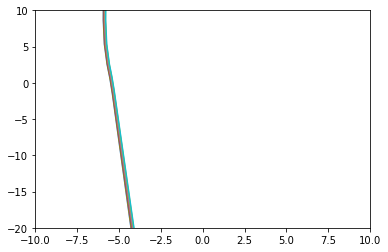

In [37]:
X = f[:,0,1]
Y = f[:,0,2]
Z = f[:,0,3]

plt.plot(Y[:,145:155], Z[:,145:155])
plt.xlim(-10,10)
plt.ylim(-20,10)